# Lab 0 Exercises
Name: Ousmane Boubacar Bako
Student ID: 30132027

In [1]:
import numpy as np

"""
Exercise 4: NumPy Array Operations
"""

# ==========================
# Task 1
# ==========================
# Create a 5x5 matrix where border elements are 1 and interior is 0

matrix = np.ones((5, 5))
matrix[1:-1, 1:-1] = 0

print("5x5 Border Matrix:")
print(matrix)


# ==========================
# Task 2
# ==========================
# Normalize a random array

np.random.seed(42)
random_data = np.random.randn(100, 3)

# Mean and standard deviation for each column
mean = random_data.mean(axis=0)
std = random_data.std(axis=0)

normalized_data = (random_data - mean) / std

print("\nColumn Means After Normalization:")
print(normalized_data.mean(axis=0))

print("\nColumn Std After Normalization:")
print(normalized_data.std(axis=0))


# ==========================
# Task 3
# ==========================
# Linear Regression using Normal Equation

X = np.random.randn(50, 3)

true_theta = np.array([2.5, -1.2, 3.7])

y = X @ true_theta + np.random.randn(50) * 0.1

# Normal Equation
theta_hat = np.linalg.inv(X.T @ X) @ X.T @ y

print("\nTrue Coefficients:")
print(true_theta)

print("\nEstimated Coefficients:")
print(theta_hat)

print("\nDifference:")
print(theta_hat - true_theta)

5x5 Border Matrix:
[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]

Column Means After Normalization:
[-2.60902411e-17  1.55431223e-17 -8.88178420e-18]

Column Std After Normalization:
[1. 1. 1.]

True Coefficients:
[ 2.5 -1.2  3.7]

Estimated Coefficients:
[ 2.51723721 -1.19783796  3.72399266]

Difference:
[0.01723721 0.00216204 0.02399266]


# Exercise 5: Pandas Data Analysis

In [ ]:
import pandas as pd
import numpy as np

"""
Exercise 5: Pandas Data Analysis
"""

# Create sample dataset
np.random.seed(42)

n_students = 200

data = {
    "student_id": range(1000, 1000 + n_students),
    "major": np.random.choice(["CS", "Math", "Physics", "Biology"], n_students),
    "year": np.random.choice([1, 2, 3, 4], n_students),
    "exam_score": np.random.normal(75, 10, n_students).clip(0, 100),
    "assignments_completed": np.random.randint(0, 11, n_students),
    "hours_studied": np.random.normal(15, 5, n_students).clip(1, 40),
}

df = pd.DataFrame(data)

# Introduce NaN values
df.loc[np.random.choice(n_students, 10), "exam_score"] = np.nan
df.loc[np.random.choice(n_students, 5), "hours_studied"] = np.nan


# ==========================
# Task 1: Data Cleaning
# ==========================

print("Dataset Information")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

# Fill exam_score using mean score of major
df["exam_score"] = df.groupby("major")["exam_score"].transform(
    lambda x: x.fillna(x.mean())
)

# Fill hours_studied using median of year
df["hours_studied"] = df.groupby("year")["hours_studied"].transform(
    lambda x: x.fillna(x.median())
)

print("\nMissing Values After Cleaning")
print(df.isnull().sum())


# ==========================
# Task 2: Analysis
# ==========================

avg_score_by_major = df.groupby("major")["exam_score"].mean()

print("\nAverage Exam Score By Major")
print(avg_score_by_major)

best_major = avg_score_by_major.idxmax()

print("\nMajor with Highest Average Score:")
print(best_major)

correlation = df["hours_studied"].corr(df["exam_score"])

print("\nCorrelation between Hours Studied and Exam Score:")
print(correlation)

# Performance Categories

df["performance"] = pd.cut(
    df["exam_score"],
    bins=[0, 70, 80, 90, 100],
    labels=["Needs Improvement", "Average", "Good", "Excellent"],
    include_lowest=True,
)

print("\nPerformance Categories")
print(df["performance"].value_counts())


# ==========================
# Task 3: Advanced Analysis
# ==========================

summary = df.groupby(["major", "year"]).agg(
    number_of_students=("student_id", "count"),
    average_exam_score=("exam_score", "mean"),
    average_hours_studied=("hours_studied", "mean"),
)

print("\nMajor-Year Summary")
print(summary)

# Top students (ties included)
top_score = df["exam_score"].nlargest(10).min()

top_students = df[df["exam_score"] >= top_score]

print("\nTop Students")
print(top_students.sort_values(by="exam_score", ascending=False))

# Pivot Table
pivot = pd.pivot_table(
    df, values="exam_score", index="major", columns="year", aggfunc="mean"
)

print("\nPivot Table")
print(pivot)

Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    str    
 2   year                   200 non-null    int64  
 3   exam_score             190 non-null    float64
 4   assignments_completed  200 non-null    int32  
 5   hours_studied          195 non-null    float64
dtypes: float64(2), int32(1), int64(2), str(1)
memory usage: 8.7 KB
None

Missing Values
student_id                0
major                     0
year                      0
exam_score               10
assignments_completed     0
hours_studied             5
dtype: int64

Missing Values After Cleaning
student_id               0
major                    0
year                     0
exam_score               0
assignments_completed    0
hours_studied            0
dtype: i

# Exercise 6: Data Visualization

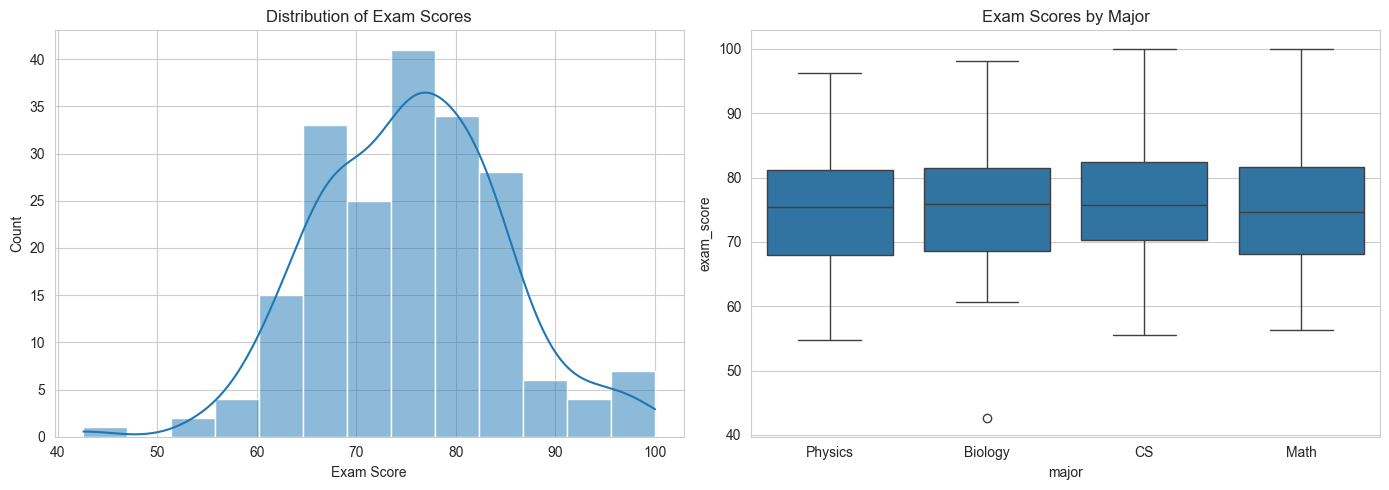

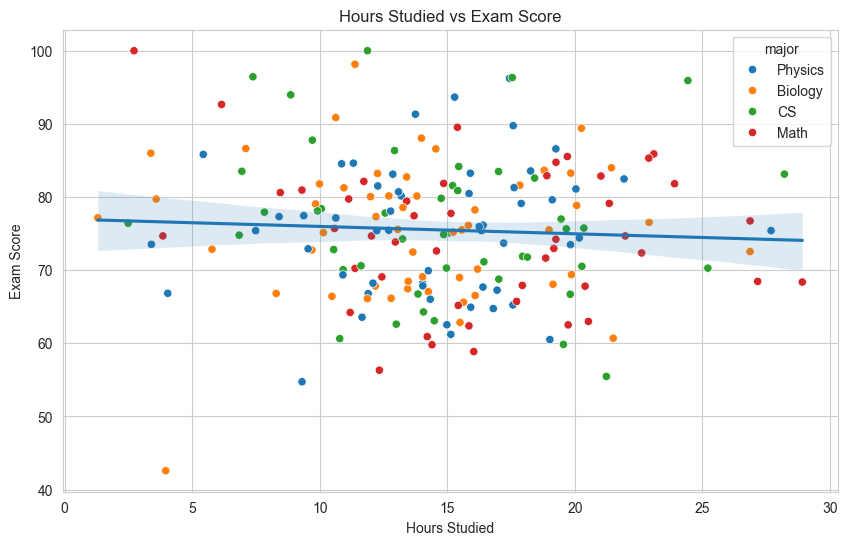

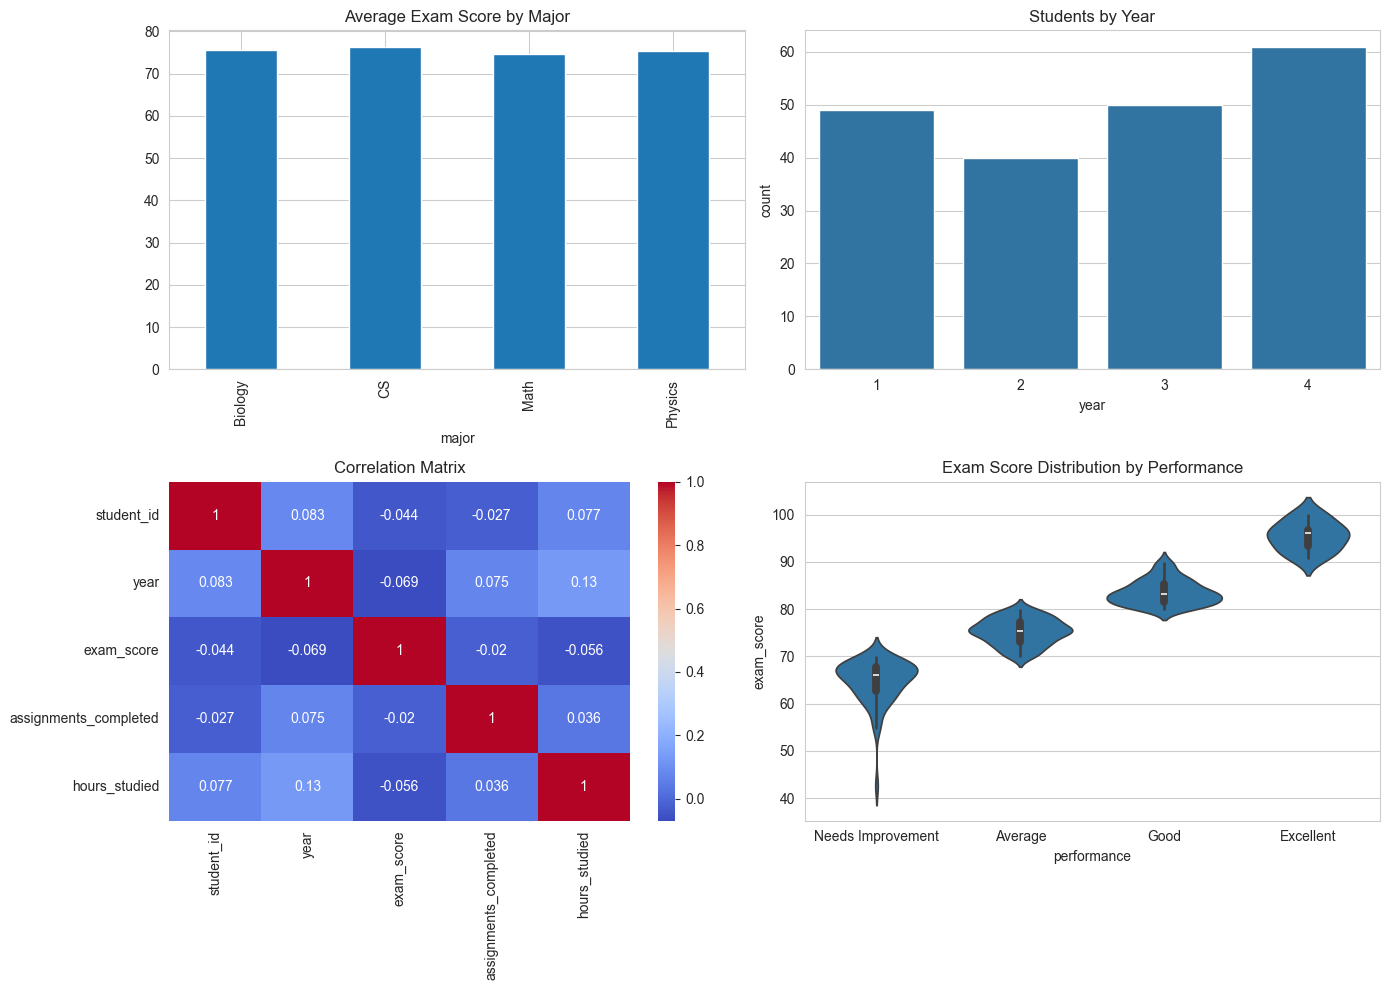

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# ==========================
# Task 1
# ==========================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["exam_score"], kde=True, ax=axes[0])

axes[0].set_title("Distribution of Exam Scores")
axes[0].set_xlabel("Exam Score")

sns.boxplot(data=df, x="major", y="exam_score", ax=axes[1])

axes[1].set_title("Exam Scores by Major")

plt.tight_layout()
plt.show()


# ==========================
# Task 2
# ==========================

plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x="hours_studied", y="exam_score", hue="major")

sns.regplot(data=df, x="hours_studied", y="exam_score", scatter=False)

plt.title("Hours Studied vs Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")

plt.show()


# ==========================
# Task 3
# ==========================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Bar Chart
avg_score_by_major.plot(kind="bar", ax=axes[0, 0])

axes[0, 0].set_title("Average Exam Score by Major")

# 2. Count Plot
sns.countplot(data=df, x="year", ax=axes[0, 1])

axes[0, 1].set_title("Students by Year")

# 3. Heatmap
numeric_cols = df.select_dtypes(include=np.number)

sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm", ax=axes[1, 0])

axes[1, 0].set_title("Correlation Matrix")

# 4. Violin Plot
sns.violinplot(data=df, x="performance", y="exam_score", ax=axes[1, 1])

axes[1, 1].set_title("Exam Score Distribution by Performance")

plt.tight_layout()
plt.show()

# Exercise 7: Integration Challenge

           number_of_customers  average_income  average_CLV      total_CLV
age_group                                                                 
18-25                       81    50634.018330   718.371170   58188.064760
26-35                       73    48747.148046   747.738562   54584.915035
36-50                      160    48516.895668   732.796612  117247.457917
51-70                      186    50713.163384   762.693498  141860.990683

Top 10% Customers
    age        income  purchase_frequency  avg_purchase_value  churn_risk  \
6    38  58876.388563                  10          110.331527    0.166667   
9    40  48809.492879                  10          110.228581    0.166667   
19   41  21282.756976                   8          119.651218    0.333333   
24   38  53981.193911                   8          120.320786    0.333333   
57   64  45956.146951                   7          135.470585    0.416667   

            CLV age_group  
6   1287.201143     36-50  
9   1286.000

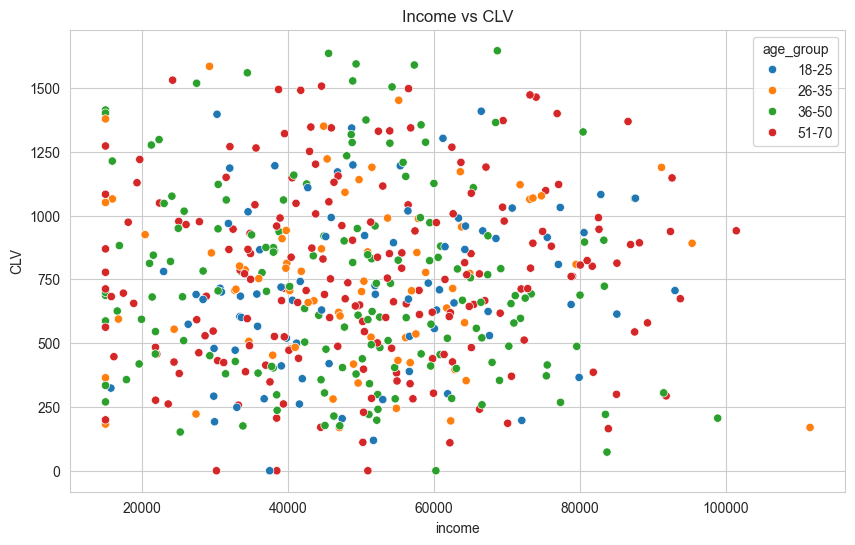

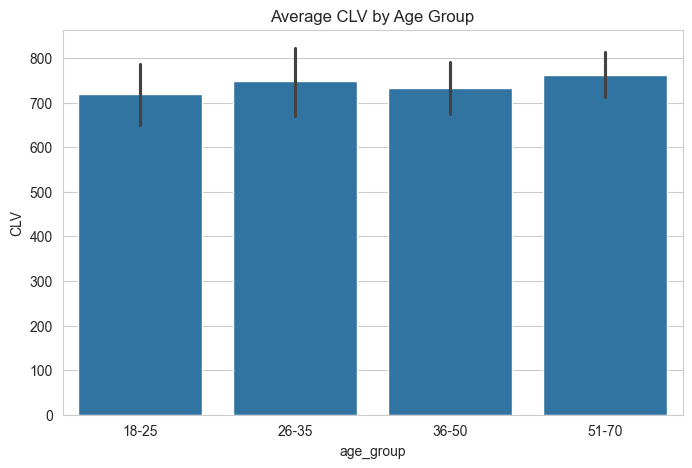

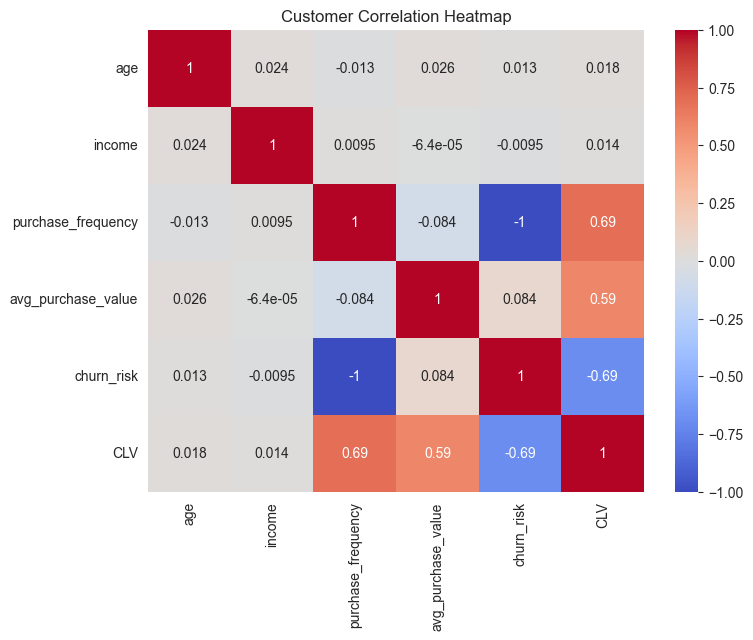

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

n_customers = 500

ages = np.random.randint(18, 70, n_customers)

income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)

purchase_freq = np.random.poisson(5, n_customers)

avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

customers = pd.DataFrame(
    {
        "age": ages,
        "income": income,
        "purchase_frequency": purchase_freq,
        "avg_purchase_value": avg_purchase_value,
    }
)

# ==========================
# CLV Calculation
# ==========================

max_frequency = customers["purchase_frequency"].max()

customers["churn_risk"] = 1 - customers["purchase_frequency"] / max_frequency

customers["CLV"] = (
    customers["purchase_frequency"]
    * customers["avg_purchase_value"]
    * (1 + customers["churn_risk"])
)

# ==========================
# Age Groups
# ==========================

customers["age_group"] = pd.cut(
    customers["age"],
    bins=[18, 25, 35, 50, 70],
    labels=["18-25", "26-35", "36-50", "51-70"],
    include_lowest=True,
)

# ==========================
# Group Analysis
# ==========================

group_summary = customers.groupby("age_group").agg(
    number_of_customers=("age", "count"),
    average_income=("income", "mean"),
    average_CLV=("CLV", "mean"),
    total_CLV=("CLV", "sum"),
)

print(group_summary)

# ==========================
# Top 10% Customers
# ==========================

threshold = customers["CLV"].quantile(0.90)

top_customers = customers[customers["CLV"] >= threshold]

print("\nTop 10% Customers")
print(top_customers.head())

# ==========================
# Visualization 1
# ==========================

plt.figure(figsize=(10, 6))

sns.scatterplot(data=customers, x="income", y="CLV", hue="age_group")

plt.title("Income vs CLV")
plt.show()

# ==========================
# Visualization 2
# ==========================

plt.figure(figsize=(8, 5))

sns.barplot(data=customers, x="age_group", y="CLV")

plt.title("Average CLV by Age Group")
plt.show()

# ==========================
# Visualization 3
# ==========================

plt.figure(figsize=(8, 6))

sns.heatmap(
    customers.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm"
)

plt.title("Customer Correlation Heatmap")
plt.show()

# Customer Analysis Summary

The analysis shows that customer lifetime value (CLV) is strongly influenced by purchase frequency and average purchase value. Those that buy more often tend to have much higher CLV.

It seems that income has a moderate positive relationship with CLV, but the relationship between high income and high expenditure is not always true. The top 10% of customers generate a disproportionate amount of overall customer value and should be addressed via loyalty programs, personalization and retention initiatives.

By analyzing age groups, it is possible to see how differences between them relate to their purchasing behaviour. The company needs to target marketing efforts towards the highest average CLV age group as well as develop methods to boost engagement for the lower performing groups.

In general, keeping the high dollar customer and increasing repeat sales will be the most effective path to long-term revenue growth.